# Tarea Sumativa Nro°3

En esta tarea se hara uso de PCA y LR. 

In [9]:
# Instalar librerías necesarias
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [10]:
# Cargar el dataset
data = pd.read_csv('./Breast_GSE45827.csv/Breast_GSE45827.csv')
# Revisar las primeras filas del dataset
data.head(5)

,samples,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,84,basal,9.850040,8.097927,6.424728,7.353027,3.029122,6.880079,4.963740,4.408328,...,12.229711,11.852955,13.658701,13.477698,6.265781,5.016196,4.901594,2.966657,3.508495,3.301999
1,85,basal,9.861357,8.212222,7.062593,7.685578,3.149468,7.542283,5.129607,4.584418,...,12.178531,11.809408,13.750086,13.470146,6.771853,5.291005,5.405839,2.934763,3.687666,3.064299
2,87,basal,10.103478,8.936137,5.735970,7.687822,3.125931,6.562369,4.813449,4.425195,...,12.125108,11.725766,13.621732,13.295080,6.346952,5.171403,5.184286,2.847684,3.550597,3.158535
3,90,basal,9.756875,7.357148,6.479183,6.986624,3.181638,7.802344,5.490982,4.567956,...,12.111235,11.719215,13.743108,13.508861,6.610284,5.193356,5.086569,3.031602,3.524981,3.272665
4,91,basal,9.408330,7.746404,6.693980,7.333426,3.169923,7.610457,5.372469,4.424426,...,12.173642,11.861296,13.797774,13.542206,6.414354,5.040202,5.235318,2.956232,3.445501,3.193947


In [8]:
# Separar caracteristicas (X) y variable objetivo (y)
# La columna 'type' contiene las clases (basal, HER, luminal_A, luminal_B, cell_line, normal)
X = data.drop('type', axis=1)
y = data['type'] 

In [12]:
# Separar en Entrenamiento y Testeo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Escalar las características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)


Número de componentes para explicar el 90% de la varianza: 75


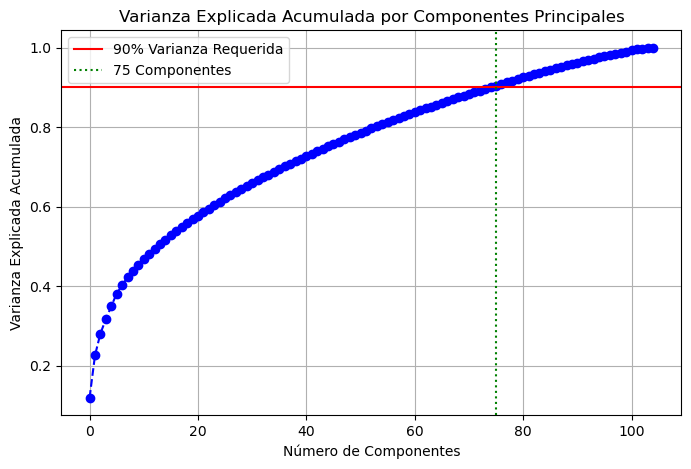

In [14]:
# Ajustar PCA con todos los componentes posibles
pca_full = PCA()
pca_full.fit(X_train_scaled)

# Calcular varianza acumulada
variance_cum = np.cumsum(pca_full.explained_variance_ratio_)

# Encontrar cuántos componentes se necesitan para el 90% de la varianza
n_components_90 = np.argmax(variance_cum >= 0.90) + 1

print(f"Número de componentes para explicar el 90% de la varianza: {n_components_90}")

# Graficar la varianza explicada acumulada
plt.figure(figsize=(8, 5))
plt.plot(variance_cum, marker='o', linestyle='--', color='b')
plt.axhline(y=0.90, color='r', linestyle='-', label='90% Varianza Requerida')
plt.axvline(x=n_components_90, color='g', linestyle=':', label=f'{n_components_90} Componentes')
plt.title('Varianza Explicada Acumulada por Componentes Principales')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.legend()
plt.grid(True)
plt.show()

# Aplicamos el PCA definitivo con el número óptimo encontrado
pca = PCA(n_components=n_components_90)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [15]:
# Obtener la matriz de loadings (componentes x variables originales)
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PC{i+1}' for i in range(n_components_90)], 
    index=X.columns
)

# Ver los 5 genes con mayor influencia absoluta en el PC1 y PC2
print("Top 5 genes que más influyen en el PC1:")
print(loadings['PC1'].abs().sort_values(ascending=False).head(5))

print("\nTop 5 genes que más influyen en el PC2:")
print(loadings['PC2'].abs().sort_values(ascending=False).head(5))

Top 5 genes que más influyen en el PC1:
206849_at     0.010652
1570281_at    0.010548
234797_at     0.010439
216102_at     0.010428
220904_at     0.010363
Name: PC1, dtype: float64

Top 5 genes que más influyen en el PC2:
233868_x_at    0.012166
232266_x_at    0.012042
200795_at      0.011991
217679_x_at    0.011972
222358_x_at    0.011959
Name: PC2, dtype: float64


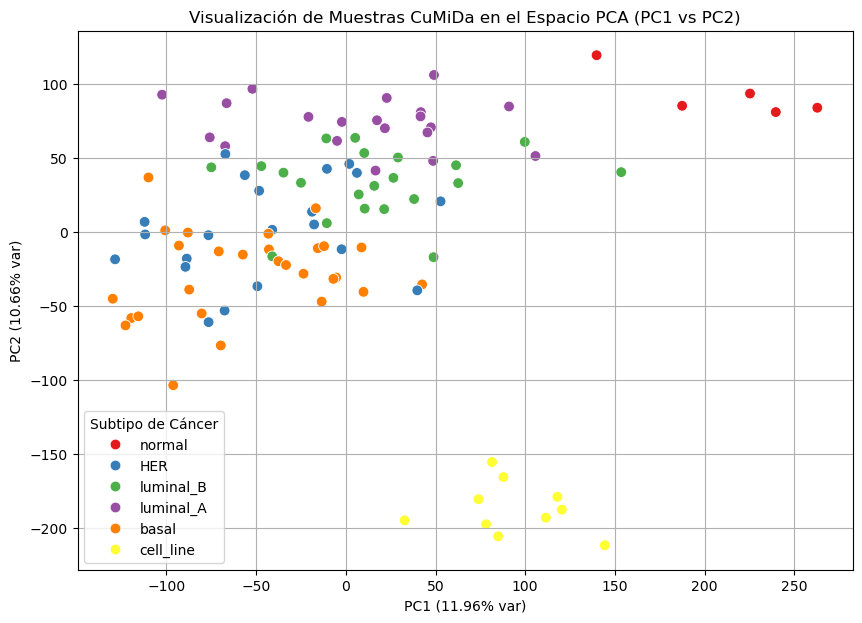

In [16]:
# Crear un DataFrame con las proyecciones de Train y sus etiquetas correspondientes
df_pca_plot = pd.DataFrame(X_train_pca[:, :2], columns=['PC1', 'PC2'])
df_pca_plot['Clase'] = y_train.values

# Graficar usando Seaborn
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Clase', data=df_pca_plot, palette='Set1', s=60)
plt.title('Visualización de Muestras CuMiDa en el Espacio PCA (PC1 vs PC2)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% var)')
plt.legend(title='Subtipo de Cáncer')
plt.grid(True)
plt.show()

In [20]:
# Instanciar el modelo base limpio
lr = LogisticRegression(max_iter=5000, solver='saga', random_state=42)

# Definir la grilla optimizada para versiones modernas de sklearn
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100]  # Ampliamos un poco hacia abajo dado el resultado
}

# Ejecutar Grid Search
grid_search = GridSearchCV(estimator=lr, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_pca, y_train)

print(f"Mejores hiperparámetros encontrados: {grid_search.best_params_}")

# Obtener predicciones finales
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_pca)

Mejores hiperparámetros encontrados: {'C': 0.001}


In [19]:
# Mostrar matriz de confusión y reporte detallado
print("=== MATRIZ DE CONFUSIÓN ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(y_test, y_pred))

=== MATRIZ DE CONFUSIÓN ===
[[ 9  0  0  0  0  0]
 [ 1 12  0  0  0  0]
 [ 0  0  4  0  0  0]
 [ 0  0  0  7  2  0]
 [ 0  0  0  0  9  0]
 [ 0  0  0  1  0  1]]

=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

         HER       0.90      1.00      0.95         9
       basal       1.00      0.92      0.96        13
   cell_line       1.00      1.00      1.00         4
   luminal_A       0.88      0.78      0.82         9
   luminal_B       0.82      1.00      0.90         9
      normal       1.00      0.50      0.67         2

    accuracy                           0.91        46
   macro avg       0.93      0.87      0.88        46
weighted avg       0.92      0.91      0.91        46



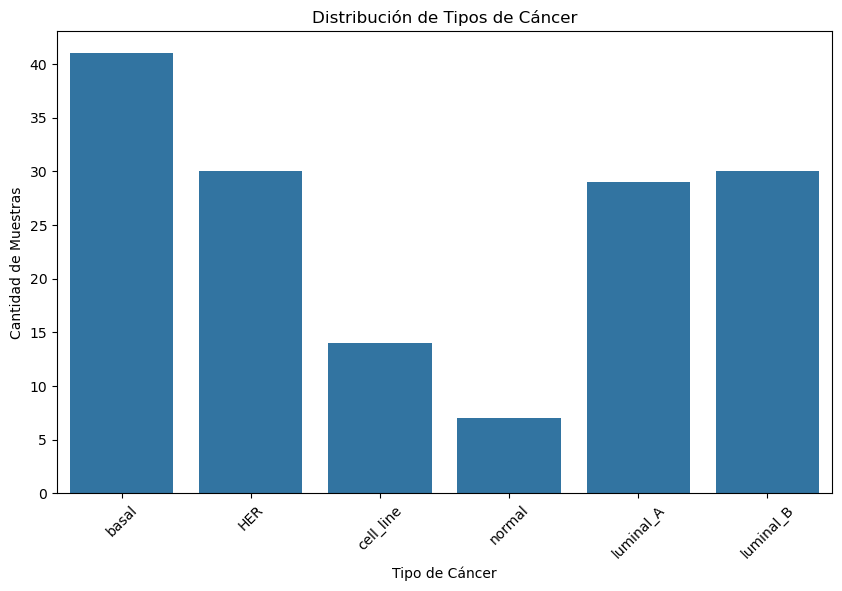

In [4]:
# Hagamos un grafico de barras para visualizar la distribución de los tipos de cáncer
plt.figure(figsize=(10, 6))
sns.countplot(x='type', data=data)
plt.title('Distribución de Tipos de Cáncer')
plt.xlabel('Tipo de Cáncer')
plt.ylabel('Cantidad de Muestras')
plt.xticks(rotation=45)
plt.show()

# Uso de PCA (no ordenado)
Dejo esto como base para hacer cambios y dejar lo considerado correcto al comienzo.

In [1]:
# Usaremos PCA considerando lo siguiente:
# - Justificar la selección de varianza explicada, 
# - Interpretar los loadings de los primeros componentes, 
# - Visualizar los primeros componentes coloreando por clase.

# Separar las características (X) y la variable objetivo (y)
X = data.drop('type', axis=1)
y = data['type']

# Estandarizar las características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Aplicar PCA
pca = PCA(n_components=2)  # Seleccionamos 2 componentes principales para visualización
X_pca = pca.fit_transform(X_scaled)

# Justificar la selección de varianza explicada
explained_variance = pca.explained_variance_ratio_
print(f'Varianza explicada por cada componente: {explained_variance}')
print(f'Varianza total explicada por los 2 componentes: {np.sum(explained_variance)}')

# Interpretar los loadings de los primeros componentes
loadings = pca.components_
print(f'Loadings del primer componente: {loadings[0]}')
print(f'Loadings del segundo componente: {loadings[1]}')

# Visualizar los primeros componentes coloreando por clase
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='Set1')
plt.title('PCA de Cáncer de Mama')
plt.xlabel('Primer Componente Principal')
plt.ylabel('Segundo Componente Principal')
plt.legend(title='Tipo de Cáncer')
plt.show()

NameError: name 'data' is not defined

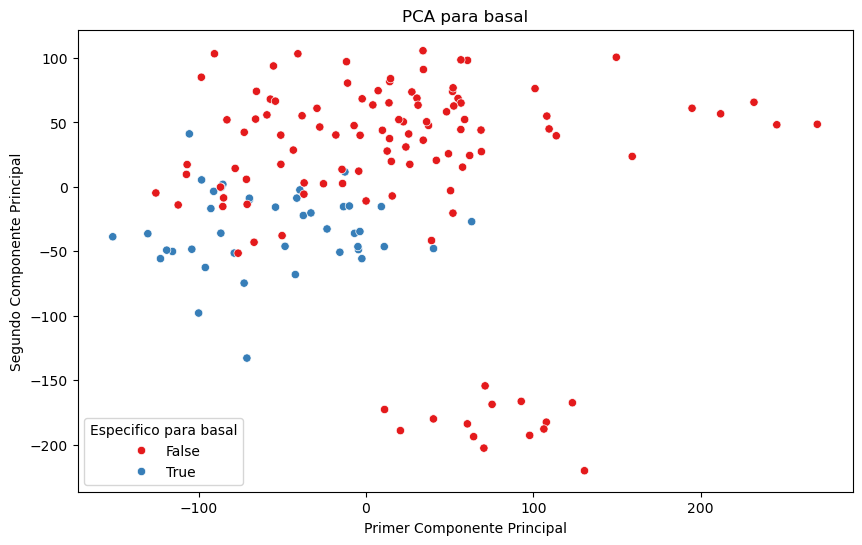

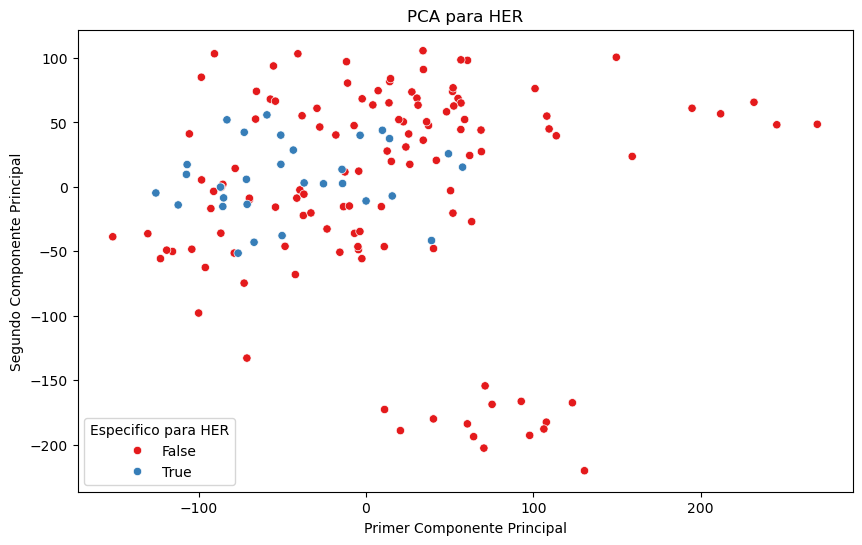

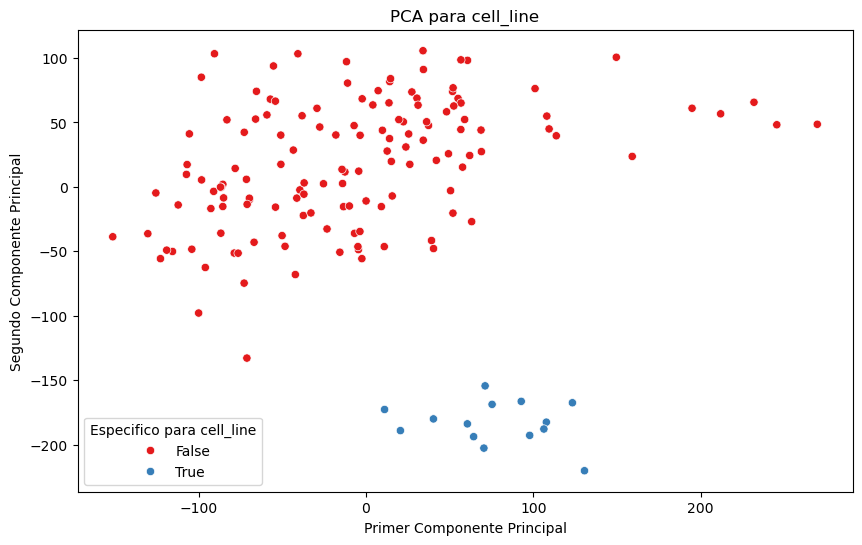

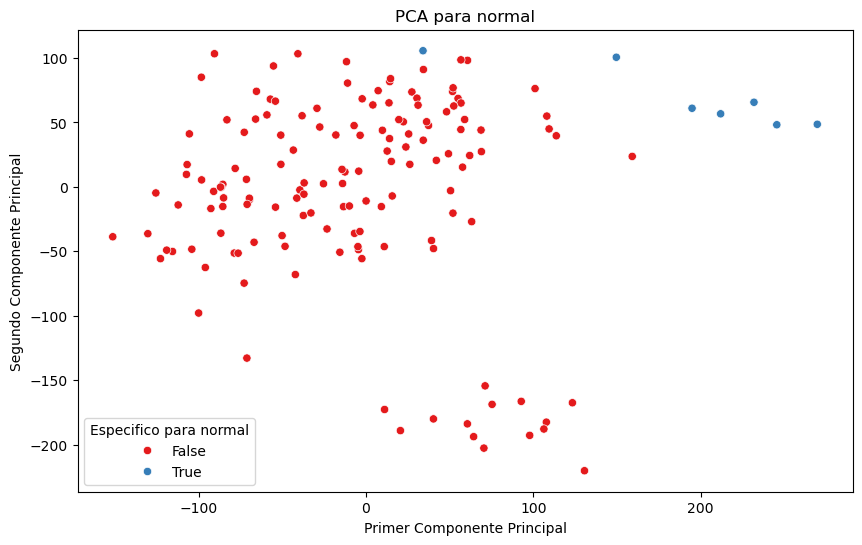

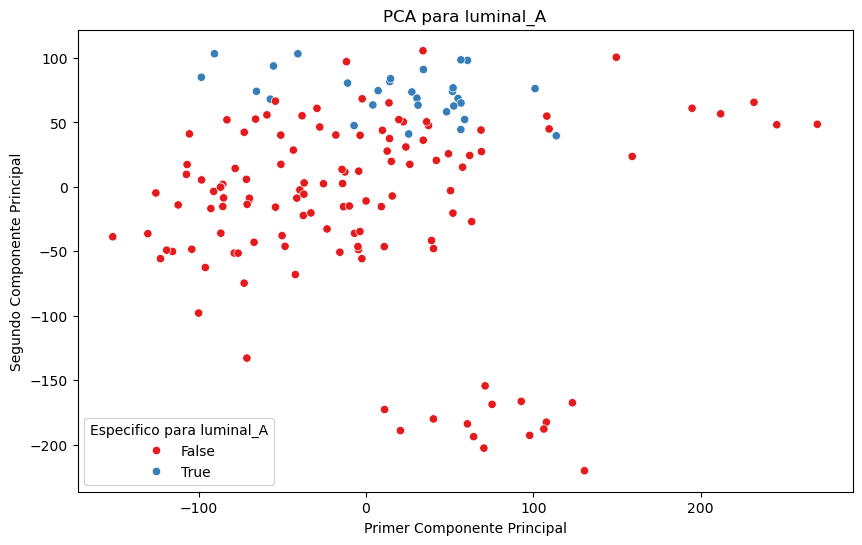

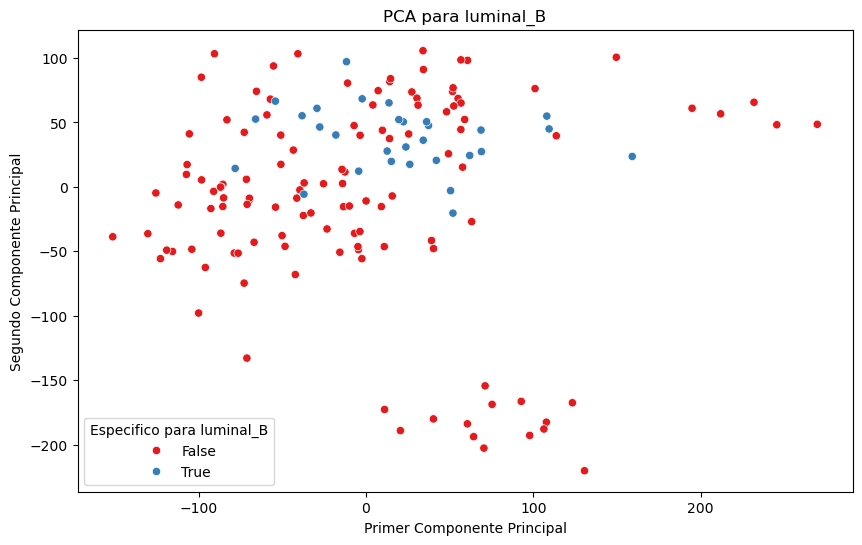

In [ ]:
# Revisar las demas etiquetas y usar PCA para visualizar cada una de ellas.
unique_labels = y.unique()
for label in unique_labels:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=(y == label), palette='Set1')
    plt.title(f'PCA para {label}')
    plt.xlabel('Primer Componente Principal')
    plt.ylabel('Segundo Componente Principal')
    plt.legend(title='Especifico para ' + label)
    plt.show()
